## ROC-AUC

AUC-ROC curve is a graph used to check how well a binary classification model works. It helps us to understand how well the model separates the positive cases like people with a disease from the negative cases like people without the disease at different threshold level. It shows how good the model is at telling the difference between the two classes by plotting:

True Positive Rate (TPR): How often the model correctly predicts the positive cases also known as Sensitivity or Recall.

False Positive Rate (FPR): How often the model incorrectly predicts a negative case as positive.

Specificity: Measures the proportion of actual negatives that the model correctly identifies. It is calculated as 1 - FPR. (SO FPR = 1 - Specifity)

-----

ROC Curve : It plots TPR vs. FPR at different thresholds. It represents the trade-off between the sensitivity and specificity of a classifier.

AUC(Area Under the Curve): measures the area under the ROC curve. A higher AUC value indicates better model performance as it suggests a greater ability to distinguish between classes. An AUC value of 1.0 indicates perfect performance while 0.5 suggests it is random guessing.

----
ROC:

Receiver Operating Characteristic = ROC

1. Parametric ROC Curve
2.
Assumes the prediction scores follow a specific statistical distribution.

Produces a smooth ROC curve.

Uses methods like Maximum Likelihood Estimation (MLE).

More mathematically complex and may not fit the actual data well if the assumption is incorrect.

2. Non-Parametric ROC Curve

Makes no assumptions about the data distribution.
Uses the actual prediction results to build the ROC curve.

Simpler and more commonly used in machine learning libraries such as scikit-learn.

Generally provides an unbiased estimate of model performance.

------------

AUC = Area under Curve

----













### ROC in Python

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target # Split the data into features (X) and target variable (y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [3]:
# Train a logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)
# Predict probabilities on the test set
y_pred_proba = model.predict_proba(X_test)[:, 1]

C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
fpr , tpr , threshould = roc_curve(y_test, y_pred_proba)

print(threshould) # from high to low
print(fpr)
print(tpr)

[           inf 9.99697036e-01 9.04979213e-01 8.95551403e-01
 8.65471816e-01 8.53022842e-01 7.91582397e-01 4.53458857e-01
 3.19264116e-01 1.88821477e-01 1.75981835e-01 4.78639200e-27]
[0.         0.         0.         0.01851852 0.01851852 0.03703704
 0.03703704 0.07407407 0.07407407 0.09259259 0.09259259 1.        ]
[0.         0.01123596 0.88764045 0.88764045 0.93258427 0.93258427
 0.97752809 0.97752809 0.98876404 0.98876404 1.         1.        ]


In [18]:
for th, fp, tp in zip(threshould, fpr, tpr):
    print(f"Threshold={th:.3f} | FPR={fp:.3f} | TPR={tp:.3f}")

Threshold=inf | FPR=0.000 | TPR=0.000
Threshold=1.000 | FPR=0.000 | TPR=0.011
Threshold=0.905 | FPR=0.000 | TPR=0.888
Threshold=0.896 | FPR=0.019 | TPR=0.888
Threshold=0.865 | FPR=0.019 | TPR=0.933
Threshold=0.853 | FPR=0.037 | TPR=0.933
Threshold=0.792 | FPR=0.037 | TPR=0.978
Threshold=0.453 | FPR=0.074 | TPR=0.978
Threshold=0.319 | FPR=0.074 | TPR=0.989
Threshold=0.189 | FPR=0.093 | TPR=0.989
Threshold=0.176 | FPR=0.093 | TPR=1.000
Threshold=0.000 | FPR=1.000 | TPR=1.000


as threshold decreases

more samples become positive.

Therefore

TPR usually increases.

FPR also usually increases.

In [15]:
roc_auc = auc(fpr, tpr)
roc_auc

0.9956304619225967

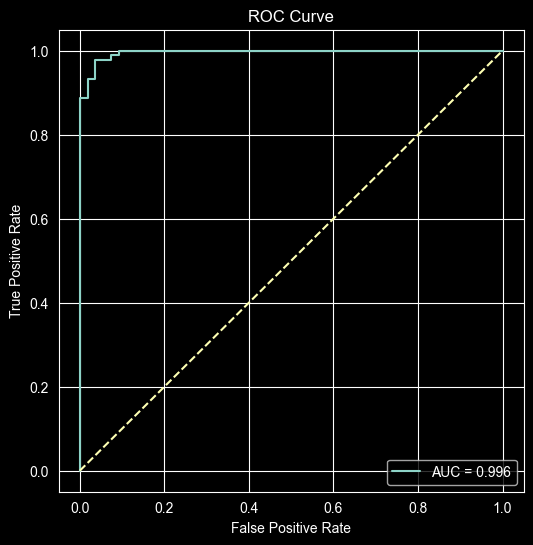

In [16]:
roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#Each dot on the curve represents one threshold.

#The dashed diagonal is the performance of a random classifier. The farther your ROC curve bows toward the upper-left corner, the better your model is at separating the two classes.

### ROC-AUC in python

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

In [20]:
X, y = make_classification(
    n_samples=1000, n_features=20, n_classes=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [21]:
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train, y_train)

random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [22]:
y_pred_logistic = logistic_model.predict_proba(X_test)[:, 1]
y_pred_rf = random_forest_model.predict_proba(X_test)[:, 1]

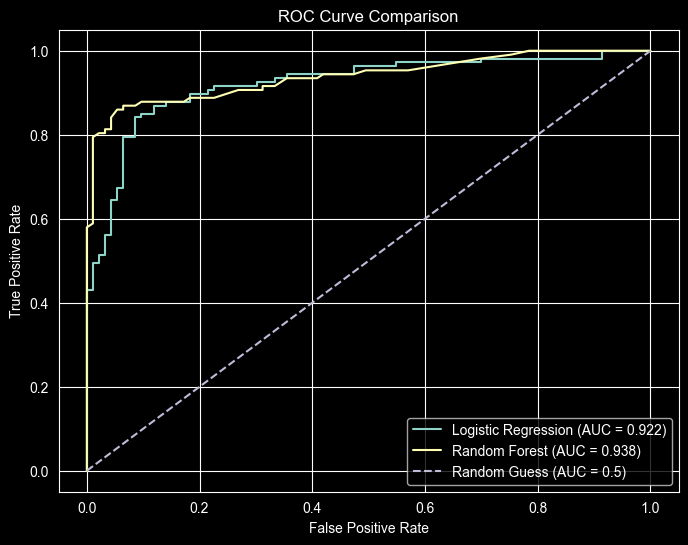

In [26]:
# ROC for Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_logistic)
auc_log = auc(fpr_log, tpr_log)

# ROC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log,
         label=f'Logistic Regression (AUC = {auc_log:.3f})')

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {auc_rf:.3f})')

# Random classifier
plt.plot([0,1], [0,1], '--', label='Random Guess (AUC = 0.5)')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

### AUC-ROC for a Multi-Class Model

For multiclass classification, AUC-ROC is extended using the One-vs-All (OvA) approach. Each class is treated as the positive class once, and the remaining classes are grouped as the negative class. For example, if you have classes A, B, C, D, you will get four ROC curves one for each class:

Class A vs. (B, C, D)

Class B vs. (A, C, D)

Class C vs. (A, B, D)

Class D vs. (A, B, C)

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from itertools import cycle

In [29]:
X, y = make_classification(
    n_samples=1000, n_features=20, n_classes=3, n_informative=10, random_state=42)

y_bin = label_binarize(y, classes=np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42)

In [30]:
logistic_model = OneVsRestClassifier(LogisticRegression(random_state=42))
logistic_model.fit(X_train, y_train)

rf_model = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, random_state=42))
rf_model.fit(X_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",RandomForestC...ndom_state=42)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int32](3,)","[0,1,2]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[RandomForestC...ndom_state=42), RandomForestC...ndom_state=42), RandomForestC...ndom_state=42)]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,True
n_classes_ n_classes_: intNumber of classes.,int,3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42


In [31]:
y_score_log = logistic_model.predict_proba(X_test)
y_score_rf = rf_model.predict_proba(X_test)

In [32]:
print(y_score_log.shape)

# ABC --> A vs BC -- B Vs AC -- C vs AB

(200, 3)


In [33]:
fpr_log = {}
tpr_log = {}
roc_auc_log = {}

for i in range(3):
    fpr_log[i], tpr_log[i], _ = roc_curve(y_test[:, i], y_score_log[:, i])
    roc_auc_log[i] = auc(fpr_log[i], tpr_log[i])

In [34]:
fpr_rf = {}
tpr_rf = {}
roc_auc_rf = {}

for i in range(3):
    fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test[:, i], y_score_rf[:, i])
    roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])

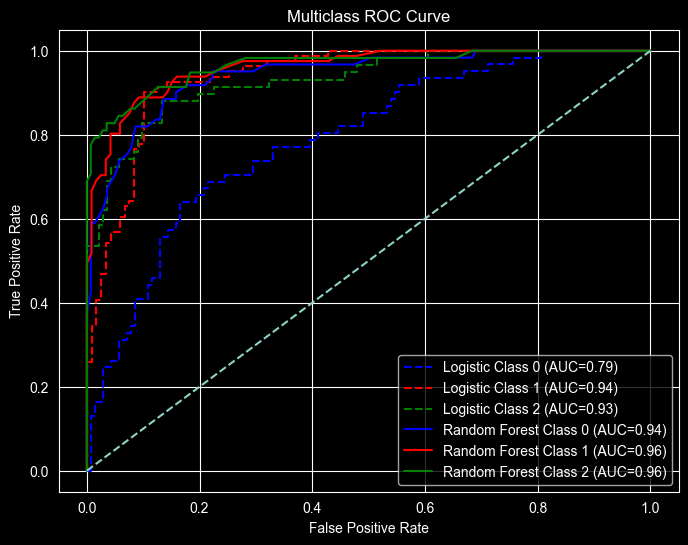

In [36]:
colors = cycle(["blue", "red", "green"])

plt.figure(figsize=(8,6))

for i, color in zip(range(3), colors):
    plt.plot(
        fpr_log[i],
        tpr_log[i],
        color=color,
        linestyle="--",
        label=f"Logistic Class {i} (AUC={roc_auc_log[i]:.2f})"
    )

colors = cycle(["blue", "red", "green"])

for i, color in zip(range(3), colors):
    plt.plot(
        fpr_rf[i],
        tpr_rf[i],
        color=color,
        label=f"Random Forest Class {i} (AUC={roc_auc_rf[i]:.2f})"
    )

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In multiclass ROC analysis, each curve represents a One-vs-Rest evaluation where one class is treated as positive and all others as negative. Each curve shows how well the model separates that specific class from the rest across different thresholds. A curve closer to the top-left indicates better separability for that class. We compare models using per-class AUC or averaged AUC scores (macro or micro) depending on whether we want equal class importance or overall performance.